The idea for this notebook is to get better understanding of NLP, LSTM, transfer learning, and ensemble techinqes. 

Baseline notebook: from https://www.kaggle.com/bibek777/lstm-baseline

Ensemble starting point is from https://machinelearningmastery.com/how-to-create-a-random-split-cross-validation-and-bagging-ensemble-for-deep-learning-in-keras

Observations:

- Weights averaging helps score a lot 
- PCA shows some missing data for test set on the chart (some words were artificially removed?)
- Baseline model overfits right after 4/5th epoch very badly
- No significant score change when using glove-6b-50d vs glove-840b-300d
- Lemmatization reduces the score 
- No significant improvement score improvement with class_weights

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from numpy import zeros

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import random
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

for dirname, _, filenames in os.walk('/kaggle/working'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

import matplotlib.pyplot as plt     
import seaborn as sns  # visualization tool

from tqdm import tqdm 

import nltk, re
#nltk.download('stopwords') # load english stopwords
#nltk.download('wordnet')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

from nltk.tokenize import TweetTokenizer
from nltk.corpus import wordnet as wn
from nltk.tokenize import word_tokenize

from collections import Counter
from itertools import chain
import pickle

import warnings
warnings.simplefilter("ignore")
warnings.warn("deprecated", DeprecationWarning)
warnings.simplefilter("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, roc_auc_score

from keras.preprocessing.text import Tokenizer
from keras.preprocessing import sequence
from keras.preprocessing.sequence import pad_sequences

from keras.layers import Input, Dense, Embedding, Dropout, LSTM, Bidirectional, Flatten, CuDNNLSTM, Conv1D
from keras.models import Model, Sequential
from keras.optimizers import Adam
from keras.constraints import unit_norm, max_norm
from keras.layers import Input, Dense, Embedding, SpatialDropout1D, add, concatenate, BatchNormalization
from keras.layers import LSTM, Bidirectional, GlobalMaxPooling1D, GlobalAveragePooling1D
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import tensorflow as tf

/kaggle/input/pickled-glove840b300d-for-10sec-loading/glove.840B.300d.pkl
/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/test.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/glove-6b-50d-txt-glove-6b-50d-pkl/__results__.html
/kaggle/input/glove-6b-50d-txt-glove-6b-50d-pkl/glove.6B.50d.pkl
/kaggle/input/glove-6b-50d-txt-glove-6b-50d-pkl/custom.css
/kaggle/input/glove-6b-50d-txt-glove-6b-50d-pkl/__notebook__.ipynb
/kaggle/input/glove-6b-50d-txt-glove-6b-50d-pkl/__output__.json
/kaggle/input/glove-6b-50d-txt-glove-6b-50d-pkl/__resultx__.html
/kaggle/working/__notebook__.ipynb


Using TensorFlow backend.


In [2]:
def seed_everything(seed=1234):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

seed_everything()

In [3]:
PATH = '/kaggle/input/nlp-getting-started/'

train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')

## Preprocess text

In [4]:
## globals

REPLACE_BY_SPACE_RE = re.compile('[/(){}\[\]\|@,;-_]')
BAD_SYMBOLS_RE = re.compile('[!"#$%&()*+,./:;<=>?@[\\]^`{|}~\t\n“”’\'∞θ÷α•à−β∅³π‘₹´°£€\×™√²—]')
UNKNOWN = 'UNK'
URL = 'URL'

#Emoji patterns
emoji_pattern = re.compile("["
         u"\U0001F600-\U0001F64F"  # emoticons
         u"\U0001F300-\U0001F5FF"  # symbols & pictographs
         u"\U0001F680-\U0001F6FF"  # transport & map symbols
         u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
         u"\U00002702-\U000027B0"
         u"\U000024C2-\U0001F251"
         "]+", flags=re.UNICODE)

## basic cleanup

In [5]:
def clean_tweet(tweet):

    if pd.isnull(tweet):
        return ''

    tweet = tweet.lower()
    tweet = tweet.replace('...', ' ... ').strip()
    tweet = tweet.replace("'", " ' ").strip()
    tweet = tweet.replace('%20', ' ').strip() 

    tweet = re.sub(r'https?://\S+|www\.\S+', URL, tweet, flags=re.MULTILINE)
    tweet = re.sub(REPLACE_BY_SPACE_RE,' ',tweet)
    tweet = re.sub(BAD_SYMBOLS_RE,'',tweet)
    tweet = re.sub(r'\d+',' ',tweet)
    tweet = re.sub(r'\s+',' ',tweet)
    tweet = re.sub(r'<.*?>', '', tweet)
    tweet = emoji_pattern.sub(r'',tweet)
    
    # delete stopwords from text
    tweet = ' '.join(w for w in nltk.wordpunct_tokenize(tweet))
    tweet = ' '.join([i for i in tweet.split() if i not in STOPWORDS])
    return tweet

train['cleaned_text'] = train['text'].apply(clean_tweet)
test['cleaned_text'] = test['text'].apply(clean_tweet)

In [6]:
train.head(10)

,id,keyword,location,text,target,cleaned_text
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,deeds reason earthquake may allah forgive us
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,forest fire near la ronge sask canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,residents asked shelter place notified officer...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,people receive wildfires evacuation orders cal...
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,got sent photo ruby alaska smoke wildfires pou...
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed...,1,rockyfire update california hwy closed directi...
6,10,NaN,NaN,#flood #disaster Heavy rain causes flash flood...,1,flood disaster heavy rain causes flash floodin...
7,13,NaN,NaN,I'm on top of the hill and I can see a fire in...,1,top hill see fire woods
8,14,NaN,NaN,There's an emergency evacuation happening now ...,1,emergency evacuation happening building across...
9,15,NaN,NaN,I'm afraid that the tornado is coming to our a...,1,afraid tornado coming area


## create full dictionary and vectorize

In [7]:
## from: https://www.kaggle.com/shahules/basic-eda-cleaning-and-glove

# WordNet lexical database for lemmatization
from nltk.stem import WordNetLemmatizer
wordnet_lemmatizer = WordNetLemmatizer()

def create_corpus(df):
    corpus=[]
    tokenizer = TweetTokenizer()
    for tweet in tqdm(df['cleaned_text']):
        words = [word.lower() for word in tokenizer.tokenize(tweet) if((word.isalpha()==1))]
        words = [wordnet_lemmatizer.lemmatize(word) for word in words] 
        corpus.append(words)
    return corpus

full = pd.concat([train,test])
corpus = create_corpus(full)

100%|██████████| 10876/10876 [00:05<00:00, 1996.85it/s]


In [8]:
MAX_LEN = 50

tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)

X_train = tokenizer.texts_to_sequences(train['cleaned_text'])
X_train = pad_sequences(X_train, maxlen=MAX_LEN, truncating='post', padding='post')    
y_train = train['target']

X_test = tokenizer.texts_to_sequences(test['cleaned_text'])
X_test = pad_sequences(X_test, maxlen=MAX_LEN, truncating='post', padding='post')    

word_index = tokenizer.word_index
print('Number of unique words:',len(word_index))

Number of unique words: 19148


## using GLOVE to create embedding vectors

In [9]:
with open('../input//glove-6b-50d-txt-glove-6b-50d-pkl/glove.6B.50d.pkl', 'rb') as fp:
#with open('../input/pickled-glove840b300d-for-10sec-loading/glove.840B.300d.pkl', 'rb') as fp:
    glove = pickle.load(fp)
    
num_words = len(word_index)+1
embedding_matrix = np.zeros((num_words, MAX_LEN))

for word,i in tqdm(word_index.items()):
    if i > num_words:
        continue
    
    emb_vec = glove.get(word)
    if emb_vec is not None:
        embedding_matrix[i]=emb_vec


100%|██████████| 19148/19148 [00:00<00:00, 253862.77it/s]


## Visualizing embedding vectors

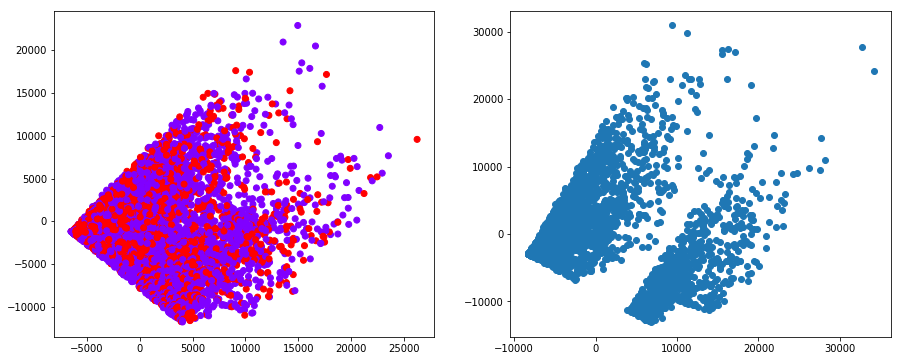

In [10]:
## Principal component analysis (PCA)

## Linear dimensionality reduction using Singular Value Decomposition of the data to project it to a lower dimensional space. 
## The input data is centered but not scaled for each feature before applying the SVD.
from sklearn.decomposition import PCA

X_pca_train = PCA(n_components=2).fit_transform(X_train)
X_pca_test = PCA(n_components=2).fit_transform(X_test)

f, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize=(15, 6))
ax1.scatter(X_pca_train[:,0],X_pca_train[:,1],c=train['target'],cmap='rainbow')
ax2.scatter(X_pca_test[:,0],X_pca_test[:,1],cmap='rainbow')

## getting class weights to balance target counts

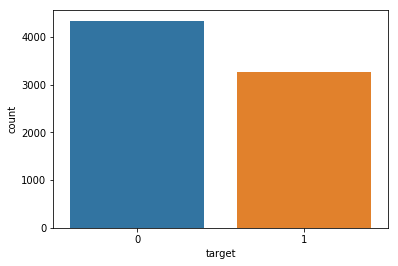

In [11]:
sns.countplot(x=y_train)

In [12]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight('balanced', np.unique(y_train), y_train)

print(class_weights) 

[0.87666974 1.1637114 ]


In [13]:
def build_model(embedding_matrix, units = 64):
    words = Input(shape=(None,))
    x = Embedding(*embedding_matrix.shape, weights=[embedding_matrix], trainable=False)(words)
    x = SpatialDropout1D(0.1)(x)
    x = Bidirectional(LSTM(units, return_sequences=True, kernel_constraint=unit_norm(), dropout=0.4, recurrent_dropout=0.4))(x)
    x = Conv1D(units, kernel_size=3, padding='valid', kernel_initializer='glorot_uniform')(x)
    x = Dropout(0.1)(x)
    x = concatenate([GlobalMaxPooling1D()(x), GlobalAveragePooling1D()(x)])    
    x = add([x, Dense(units*2, activation='relu', kernel_constraint=unit_norm())(x)])
    x = BatchNormalization()(x)
    result = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=words, outputs=result)
    adam = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
    model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['acc'])
    return model

In [14]:

# evaluate a single mlp model
def evaluate_model(fold, trainX, trainy, testX, testy, embedding_matrix, class_weights, epochs = 5, batch_size=100, units = 128):
    ckpt = ModelCheckpoint(f'lstm_{fold}.hdf5', save_best_only = True, save_weights_only = True)
    es = EarlyStopping(monitor='val_loss', patience=5, mode='min', baseline=None, restore_best_weights=False)
    # define model
    model = build_model(embedding_matrix, units)    
    # fit model
    history = model.fit(trainX, trainy, epochs=epochs, verbose=1, validation_data=(testX, testy), 
                        class_weight=class_weights, batch_size=batch_size, callbacks=[es, ckpt])
    print('loss %.3f (%.3f)' % (np.mean(history.history['loss']), np.std(history.history['loss'])))   
    print('val-loss %.3f (%.3f)' % (np.mean(history.history['val_loss']), np.std(history.history['val_loss'])))   
    print('acc %.3f (%.3f)' % (np.mean(history.history['acc']), np.std(history.history['acc'])))   
    print('val-acc %.3f (%.3f)' % (np.mean(history.history['val_acc']), np.std(history.history['val_acc'])))
    # make predictions
    y_pred = model.predict(testX)
    predictions = (y_pred > 0.5).astype(int).ravel()
    return model, predictions, history

# make an ensemble prediction for binary classification
def ensemble_predictions(members, testX):
    # make predictions
    yhats = [model.predict(testX) for model in members]
    predictions = np.mean(np.array(yhats), axis=0)
    return (predictions > 0.5).astype(int).ravel()
 
# evaluate a specific number of members in an ensemble
def evaluate_n_members(members, n_members, testX, testy):
    # select a subset of members
    subset = members[:n_members]
    # make prediction
    yhat = ensemble_predictions(subset, testX)
    # calculate accuracy
    return accuracy_score(testy, yhat), yhat

# splits data into train and test sets
def split_dataset(X, y, n_samples):
    ix = [i for i in range(len(X))]
    train_ix = resample(ix, replace=True, n_samples=n_samples)
    test_ix = resample(ix, replace=True, n_samples=len(X)-len(train_ix))
    return X[train_ix], y[train_ix], X[test_ix], y[test_ix]

In [15]:
BATCH_SIZE = 512
EPOCHS = 100
UNITS = 64
FOLDS = 3

seed_everything(42)    

predictions, scores, models = [], [], []
for fold in range(FOLDS):
    trainX, trainy, testX, testy = split_dataset(X_train, y_train, 6000)
    model, y_pred, history = evaluate_model(fold, trainX, trainy, testX, testy, 
                                            embedding_matrix, class_weights, epochs = EPOCHS, batch_size=BATCH_SIZE, units=UNITS)
    scores.append(np.mean(history.history['acc']))
    predictions.append(y_pred)
    models.append(model)

# summarize expected performance
print("Estimated Accuracy: %.2f%% (+/- %.2f%%)" % (np.mean(scores), np.std(scores)))        

Train on 6000 samples, validate on 1613 samples
Epoch 1/100
6000/6000 [==============================] - 8s 1ms/step - loss: 0.6484 - acc: 0.6628 - val_loss: 0.6033 - val_acc: 0.7570
Epoch 2/100
6000/6000 [==============================] - 5s 877us/step - loss: 0.5469 - acc: 0.7328 - val_loss: 0.6058 - val_acc: 0.7545
Epoch 3/100
6000/6000 [==============================] - 5s 876us/step - loss: 0.5265 - acc: 0.7480 - val_loss: 0.5832 - val_acc: 0.7843
Epoch 4/100
6000/6000 [==============================] - 5s 872us/step - loss: 0.5191 - acc: 0.7500 - val_loss: 0.5676 - val_acc: 0.7750
Epoch 5/100
6000/6000 [==============================] - 5s 860us/step - loss: 0.5124 - acc: 0.7563 - val_loss: 0.5590 - val_acc: 0.7849
Epoch 6/100
6000/6000 [==============================] - 5s 849us/step - loss: 0.5037 - acc: 0.7635 - val_loss: 0.5483 - val_acc: 0.7998
Epoch 7/100
6000/6000 [==============================] - 5s 916us/step - loss: 0.4981 - acc: 0.7653 - val_loss: 0.5361 - val_acc: 0.

In [16]:
# evaluate different numbers of ensembles on hold out set
ensemble_scores = list()
for i in range(1, FOLDS+1):
    ensemble_score, _ = evaluate_n_members(models, i, X_train, y_train)
    print('> %d: single=%.3f, ensemble=%.3f' % (i, scores[i-1], ensemble_score))
    ensemble_scores.append(ensemble_score)

print('Single Accuracy %.3f (%.3f)' % (np.mean(scores), np.std(scores)))   
print('Ensemble accuracy %.3f (%.3f)' % (np.mean(ensemble_score), np.std(ensemble_score)))

> 1: single=0.817, ensemble=0.870
> 2: single=0.828, ensemble=0.881
> 3: single=0.818, ensemble=0.886
Single Accuracy 0.821 (0.005)
Ensemble accuracy 0.886 (0.000)


## plot single vs ensemble scores

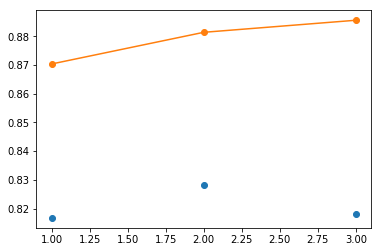

In [17]:
x_axis = [i for i in range(1, FOLDS+1)]
plt.plot(x_axis, scores, marker='o', linestyle='None')
plt.plot(x_axis, ensemble_scores, marker='o')
plt.show()

## now load best saved weights and get scrores

In [18]:
for i in range(FOLDS):
    models[i].load_weights(f'/kaggle/working/lstm_{i}.hdf5')

# make predictions for train set for comparison
y_pred = ensemble_predictions(models, X_train)

print('ROC AUC')
print(roc_auc_score(y_train, y_pred))
print('Confusion Matrix')
print(confusion_matrix(y_train, y_pred))
print('Classification Report')
print(classification_report(y_train, y_pred))


ROC AUC
0.8750450795138552
Confusion Matrix
[[4056  286]
 [ 602 2669]]
Classification Report
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4342
           1       0.90      0.82      0.86      3271

    accuracy                           0.88      7613
   macro avg       0.89      0.88      0.88      7613
weighted avg       0.88      0.88      0.88      7613



## Submission

In [19]:
y_pred = ensemble_predictions(models, X_test)

sample_sub = pd.read_csv('../input/nlp-getting-started/sample_submission.csv')
sub = pd.DataFrame({'id':sample_sub['id'].values.tolist(),'target':y_pred})
sub.to_csv('submission.csv',index=False)

In [20]:
sub['tweet'] = test['text']
sub.head(25)

,id,target,tweet
0,0,1,Just happened a terrible car crash
1,2,1,"Heard about #earthquake is different cities, s..."
2,3,1,"there is a forest fire at spot pond, geese are..."
3,9,1,Apocalypse lighting. #Spokane #wildfires
4,11,1,Typhoon Soudelor kills 28 in China and Taiwan
5,12,1,We're shaking...It's an earthquake
6,21,0,They'd probably still show more life than Arse...
7,22,0,Hey! How are you?
8,27,0,What a nice hat?
9,29,0,Fuck off!
